Install Dependencies

In [1]:
!pip install -q bitsandbytes accelerate peft transformers datasets trl fsspec==2025.3.2 -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Set Random Seeds for Reproducibility

In [2]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Optional: make PyTorch even more deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Set dataset path

In [4]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_multiturn.jsonl"
print("Dataset path:", DATASET_PATH)

import os

if os.path.exists(DATASET_PATH):
    print("✅ Dataset found!")
else:
    print("❌ Dataset not found. Check the path.")


Dataset path: /content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_multiturn.jsonl
✅ Dataset found!


Convert Dataset for Training

In [5]:
import json

# Use the Google Drive project path for input and output files
input_file = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_multiturn.jsonl"
output_file = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_for_lora.jsonl"

with open(input_file, "r", encoding="utf-8") as f_in, open(output_file, "w", encoding="utf-8") as f_out:
    for line in f_in:
        data = json.loads(line)
        converted = {
            "instruction": data["prompt"].strip(),
            "output": data["response"].strip()
        }
        json.dump(converted, f_out, ensure_ascii=False)
        f_out.write("\n")

print(f"✅ Converted to {output_file}")


✅ Converted to /content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_for_lora.jsonl


Load Converted Dataset

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Use full paths for Drive-based project directory
converted_path = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/training_data_for_lora.jsonl"
train_path = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/train_split.jsonl"
val_path = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/val_split.jsonl"

# Load the converted dataset as DataFrame
df = pd.read_json(converted_path, lines=True)

# Stratified split (or random if no source_user)
if 'source_user' in df.columns:
    stratify_col = df['source_user']
else:
    stratify_col = None

train_df, val_df = train_test_split(
    df,
    test_size=0.05,
    stratify=stratify_col,
    random_state=42
)

# Save the splits to JSONL files in your project directory
train_df.to_json(train_path, orient="records", lines=True)
val_df.to_json(val_path, orient="records", lines=True)

print(f"✅ Train/val split done. Train size: {len(train_df)}, Val size: {len(val_df)}")
print("Train split path:", train_path)
print("Val split path:", val_path)


✅ Train/val split done. Train size: 26382, Val size: 1389
Train split path: /content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/train_split.jsonl
Val split path: /content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/val_split.jsonl


Load Datasets Separately

In [7]:
import pandas as pd
from datasets import Dataset

# Use your Drive paths
train_file = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/train_split.jsonl"
val_file = "/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/data/val_split.jsonl"

# Load using pandas
train_df = pd.read_json(train_file, lines=True)
val_df = pd.read_json(val_file, lines=True)

# Convert to HuggingFace Dataset objects
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

print(f"✅ Loaded train dataset with {len(train_dataset)} samples")
print(f"✅ Loaded val dataset with {len(val_dataset)} samples")


✅ Loaded train dataset with 26382 samples
✅ Loaded val dataset with 1389 samples


Log in to Hugging Face

In [8]:
from huggingface_hub import login

login()


Load Model + Tokenizer (4-bit Quantized)

In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

# Load base model + tokenizer
model_name = "mistralai/Mistral-7B-v0.1"

# Use bfloat16 if supported, else fallback to float16
compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

bnb_config = dict(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", **bnb_config)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Prepare for LoRA fine-tuning
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

print("✅ Model loaded, quantized, and LoRA-ready.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

✅ Model loaded, quantized, and LoRA-ready.


Train Model with LoRA

In [10]:
from transformers import TrainingArguments
from trl import SFTTrainer

# With A100, try a higher batch size. If you OOM, halve this number.
PER_DEVICE_BATCH_SIZE = 24  # Try 8, go up/down as VRAM allows

steps_per_epoch = len(train_dataset) // (PER_DEVICE_BATCH_SIZE * 1)  # grad_accum = 1

training_args = TrainingArguments(
    output_dir="gurt-mistral-lora",
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=1,
    num_train_epochs=2,
    logging_steps=10,
    eval_steps=steps_per_epoch,
    save_strategy="epoch",
    learning_rate=2e-4,
    bf16=True,
    dataloader_num_workers=2,
    report_to="none",
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
)


trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="instruction",
    args=training_args,
    max_seq_length=2048
)


trainer.train()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/26382 [00:00<?, ? examples/s]

Map:   0%|          | 0/1389 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:396: UserWarning: You passed a tokenizer with `padding_side` not equal to `right` to the SFTTrainer. This might lead to some unexpected behaviour due to overflow issues when training a model in half-precision. You might consider adding `tokenizer.padding_side = 'right'` to your code.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:401: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/e

Step,Training Loss
10,4.124300
20,4.023200
30,3.705000
40,3.353800
50,3.191400
60,3.037700
70,3.005100
80,2.915100
90,2.945300
100,2.909400


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=2200, training_loss=2.5207307529449463, metrics={'train_runtime': 2420.7546, 'train_samples_per_second': 21.797, 'train_steps_per_second': 0.909, 'total_flos': 2.2832654664425472e+17, 'train_loss': 2.5207307529449463, 'epoch': 2.0})

Plot Training/Validation Loss After Training

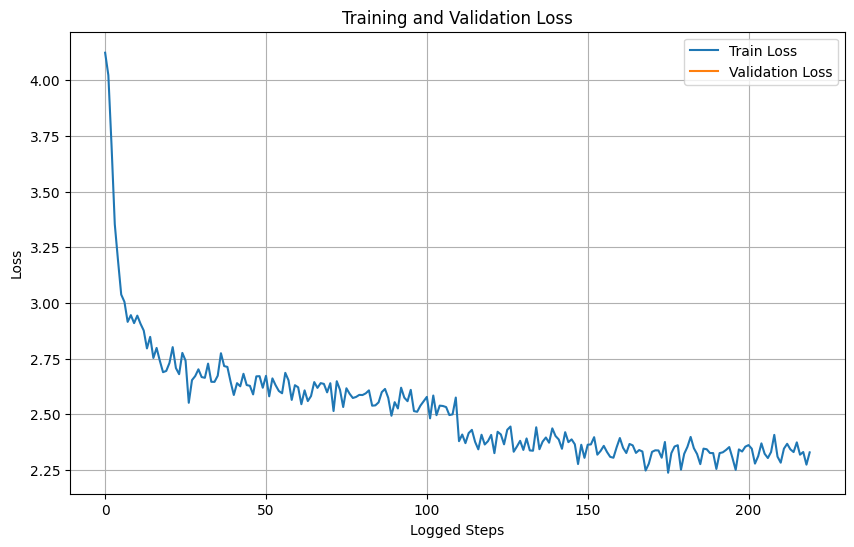

In [11]:
import matplotlib.pyplot as plt

# Extract loss values from the trainer log history
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.xlabel('Logged Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()


Save LoRA Adapter & Tokenizer + Export to Drive

In [12]:
import os
import time

# Define where to save in Colab
save_dir = "/content/gurt-mistral-lora"

# Save LoRA adapter and tokenizer
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"✅ Model and tokenizer saved to: {save_dir}")

# List saved files for confirmation
print("Saved files:", os.listdir(save_dir))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save to WhatsApp Bot project directory with timestamp
timestamp = time.strftime("%Y%m%d-%H%M%S")
backup_dir = f"/content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/gurt-mistral-lora-{timestamp}"

# Copy to Google Drive with timestamped directory
!cp -r {save_dir} {backup_dir}
print(f"✅ Backup saved to Google Drive at: {backup_dir}")

# Optional: Unmount Google Drive after backup
drive.flush_and_unmount()


✅ Model and tokenizer saved to: /content/gurt-mistral-lora
Saved files: ['tokenizer.model', 'adapter_model.safetensors', 'checkpoint-1100', 'tokenizer_config.json', 'adapter_config.json', 'tokenizer.json', 'README.md', 'checkpoint-2200', 'special_tokens_map.json']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: target 'Bot/gurt-mistral-lora-20250518-151111' is not a directory
✅ Backup saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/WhatsApp Bot/gurt-mistral-lora-20250518-151111


Generate Sample Completions After Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import pipeline

# Load model and tokenizer from your save_dir
model_path = save_dir
pipe = pipeline(
    "text-generation",
    model=model_path,
    tokenizer=model_path,
    device=0,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

# Example prompt: prompt format should match your training data!
prompt = "Mark: Bro did you actually clean the sink this time?\nElias:\nGurt:"

output = pipe(
    prompt,
    max_new_tokens=40,         # Lower than before, tighter answers
    do_sample=True,
    top_p=0.92,
    temperature=0.7,
)
print("Prompt:\n", prompt)
print("Model completion:\n", output[0]['generated_text'][len(prompt):])  # Only print generated part


Save config/hyperparameters as a text file

In [14]:
config_info = f"""
Model: {model_name}
Batch size: {PER_DEVICE_BATCH_SIZE}
Learning rate: 2e-4
Epochs: 2
Scheduler: cosine
Warmup ratio: 0.05
Context window (max_seq_length): 2048
LoRA r: 16
LoRA alpha: 32
LoRA dropout: 0.05
Target modules: ['q_proj', 'v_proj']
"""

with open(f"{save_dir}/training_config.txt", "w") as f:
    f.write(config_info.strip())

print(f"✅ Training config saved to {save_dir}/training_config.txt")


✅ Training config saved to /content/gurt-mistral-lora/training_config.txt
